<a href="https://colab.research.google.com/github/jalipe-cloud/aprendizaje-maquina/blob/main/caso3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de Recomendación de Artículos Similares (NMF + Similitud de Coseno)

**Escenario:** Somos el equipo de Machine Learning de un periódico en línea. Se nos pide: dado un artículo que el lector está viendo actualmente, recomendar otros artículos con temas similares.

**Dataset:** Usamos el dataset **20 Newsgroups** de scikit-learn como conjunto de "artículos" (son publicaciones de foros de discusión con distintos temas — ciencia, deportes, política, tecnología, etc. — que funcionan como un buen sustituto de artículos periodísticos con distintas secciones/temas).

**Enfoque:**
1. Vectorizar los artículos con **TF-IDF**.
2. Reducir a un espacio de **temas (topics)** usando **NMF** (Non-negative Matrix Factorization), que es interpretable: cada tema queda representado por un conjunto de palabras clave, y cada artículo por una mezcla de temas.
3. Representar cada artículo por su vector de temas y calcular la **similitud de coseno** entre artículos para recomendar los más parecidos.

**Contenido:**
1. Carga y exploración del dataset
2. Preprocesamiento de texto
3. Vectorización TF-IDF
4. Extracción de temas con NMF
5. Interpretación de los temas encontrados
6. Motor de recomendación (similitud de coseno sobre el espacio de temas)
7. Evaluación del sistema
8. Recomendación para un artículo nuevo (fuera del dataset)
9. Conclusiones

In [ ]:
# Instalación / importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

import nltk
import re
import string
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

np.random.seed(42)

## 1. Carga y exploración del dataset

Usamos varias categorías de temas distintos, simulando distintas "secciones" de un periódico (tecnología, deportes/recreación, política, ciencia, etc.).

In [ ]:
# Selección de categorías (simulan secciones del periódico)
categories = [
    'sci.space',            # Ciencia
    'sci.med',               # Salud
    'rec.sport.baseball',    # Deportes
    'rec.autos',             # Autos
    'comp.graphics',         # Tecnología
    'talk.politics.mideast', # Política / Internacional
]

# Workaround para el error 403 Forbidden (servidor de figshare requiere User-Agent)
import urllib.request
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)')]
urllib.request.install_opener(opener)

import time
max_intentos = 3
news_data = None
for intento in range(1, max_intentos + 1):
    try:
        news_data = fetch_20newsgroups(
            subset='train',
            categories=categories,
            shuffle=True,
            random_state=42,
            remove=('headers', 'footers', 'quotes'),
            download_if_missing=True
        )
        break
    except Exception as e:
        print(f"Intento {intento} fallido: {e}")
        if intento < max_intentos:
            time.sleep(3)

if news_data is None:
    raise RuntimeError(
        "No se pudo descargar el dataset 20 Newsgroups tras varios intentos. "
        "Reinicia el entorno de ejecución (Entorno de ejecución > Reiniciar entorno "
        "de ejecución) y vuelve a correr la celda."
    )

df = pd.DataFrame({
    'texto': news_data.data,
    'categoria_id': news_data.target,
    'categoria': [news_data.target_names[i] for i in news_data.target]
})

# Eliminar artículos vacíos o demasiado cortos
df = df[df['texto'].str.strip().str.len() > 100].reset_index(drop=True)

print(f"Total de artículos: {len(df)}")
print(f"\nDistribución por sección:")
print(df['categoria'].value_counts())

Total de artículos: 3162

Distribución por sección:
categoria
sci.med                  559
sci.space                547
comp.graphics            525
rec.autos                515
talk.politics.mideast    512
rec.sport.baseball       504
Name: count, dtype: int64


In [ ]:
df.head(3)

## 2. Preprocesamiento de texto

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english') + list(string.punctuation))

def clean_text(text):
    """Limpieza y lematización de texto"""
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.lower()

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]

    return ' '.join(tokens)

df['texto_limpio'] = df['texto'].apply(clean_text)

print("Ejemplo de texto original:")
print(df['texto'].iloc[0][:300])
print("\nEjemplo de texto limpio:")
print(df['texto_limpio'].iloc[0][:300])

Ejemplo de texto original:
I am currently looking for a 3D graphics library that runs on MS
Windows 3.1.  Are there any such libraries out there other than
Visuallib?  (It must run on VGA and should not require any other
add-on graphics cards).

For Visuallib, will it run with Metaware High C compiler v3.0?  Any
email contact

Ejemplo de texto limpio:
currently looking graphic library run window library visuallib must run vga require add graphic card visuallib run metaware high compiler email contact author visuallib help would much appreciated thanks


## 3. Vectorización TF-IDF

Convertimos cada artículo en un vector numérico basado en la frecuencia de términos ponderada por su relevancia (TF-IDF).

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=3,
    max_df=0.85,
    stop_words='english',
    ngram_range=(1, 1)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['texto_limpio'])
print(f"Dimensión de la matriz TF-IDF: {tfidf_matrix.shape}")
print(f"(número de artículos x número de términos)")

Dimensión de la matriz TF-IDF: (3162, 3000)
(número de artículos x número de términos)


## 4. Extracción de temas con NMF

NMF factoriza la matriz TF-IDF (no negativa) en dos matrices no negativas:

$$ V \approx W \times H $$

- **W** (artículos x temas): qué tan presente está cada tema en cada artículo.
- **H** (temas x términos): qué tan importante es cada palabra dentro de cada tema.

Elegimos un número de temas razonable (aproximado al número de secciones del periódico, aunque NMF puede descubrir subtemas más finos).

In [ ]:
N_TOPICS = 8  # número de temas a extraer

nmf_model = NMF(
    n_components=N_TOPICS,
    init='nndsvda',
    random_state=42,
    max_iter=500
)

W = nmf_model.fit_transform(tfidf_matrix)  # (n_articulos, n_topics) -> representación de artículos por tema
H = nmf_model.components_                  # (n_topics, n_terminos) -> palabras clave por tema

print(f"Matriz W (artículos x temas): {W.shape}")
print(f"Matriz H (temas x términos): {H.shape}")

Matriz W (artículos x temas): (3162, 8)
Matriz H (temas x términos): (8, 3000)


## 5. Interpretación de los temas encontrados

In [ ]:
def mostrar_top_palabras_por_tema(H, feature_names, n_palabras=10):
    for topic_idx, topic in enumerate(H):
        top_indices = topic.argsort()[::-1][:n_palabras]
        top_palabras = [feature_names[i] for i in top_indices]
        print(f"Tema {topic_idx}: {', '.join(top_palabras)}")

feature_names = tfidf_vectorizer.get_feature_names_out()
mostrar_top_palabras_por_tema(H, feature_names)

Tema 0: file, graphic, thanks, image, program, format, know, color, mail, window
Tema 1: geb, cadre, dsl, chastity, jxp, pitt, skepticism, shameful, surrender, intellect
Tema 2: armenian, turkish, armenia, turk, turkey, people, genocide, muslim, azeri, greek
Tema 3: game, team, year, player, run, hit, win, pitching, baseball, fan
Tema 4: car, engine, dealer, price, new, speed, good, model, like, mile
Tema 5: israel, israeli, arab, jew, palestinian, jewish, state, peace, right, lebanon
Tema 6: space, nasa, launch, shuttle, orbit, satellite, moon, lunar, earth, mission
Tema 7: people, like, think, thing, msg, food, time, know, problem, say


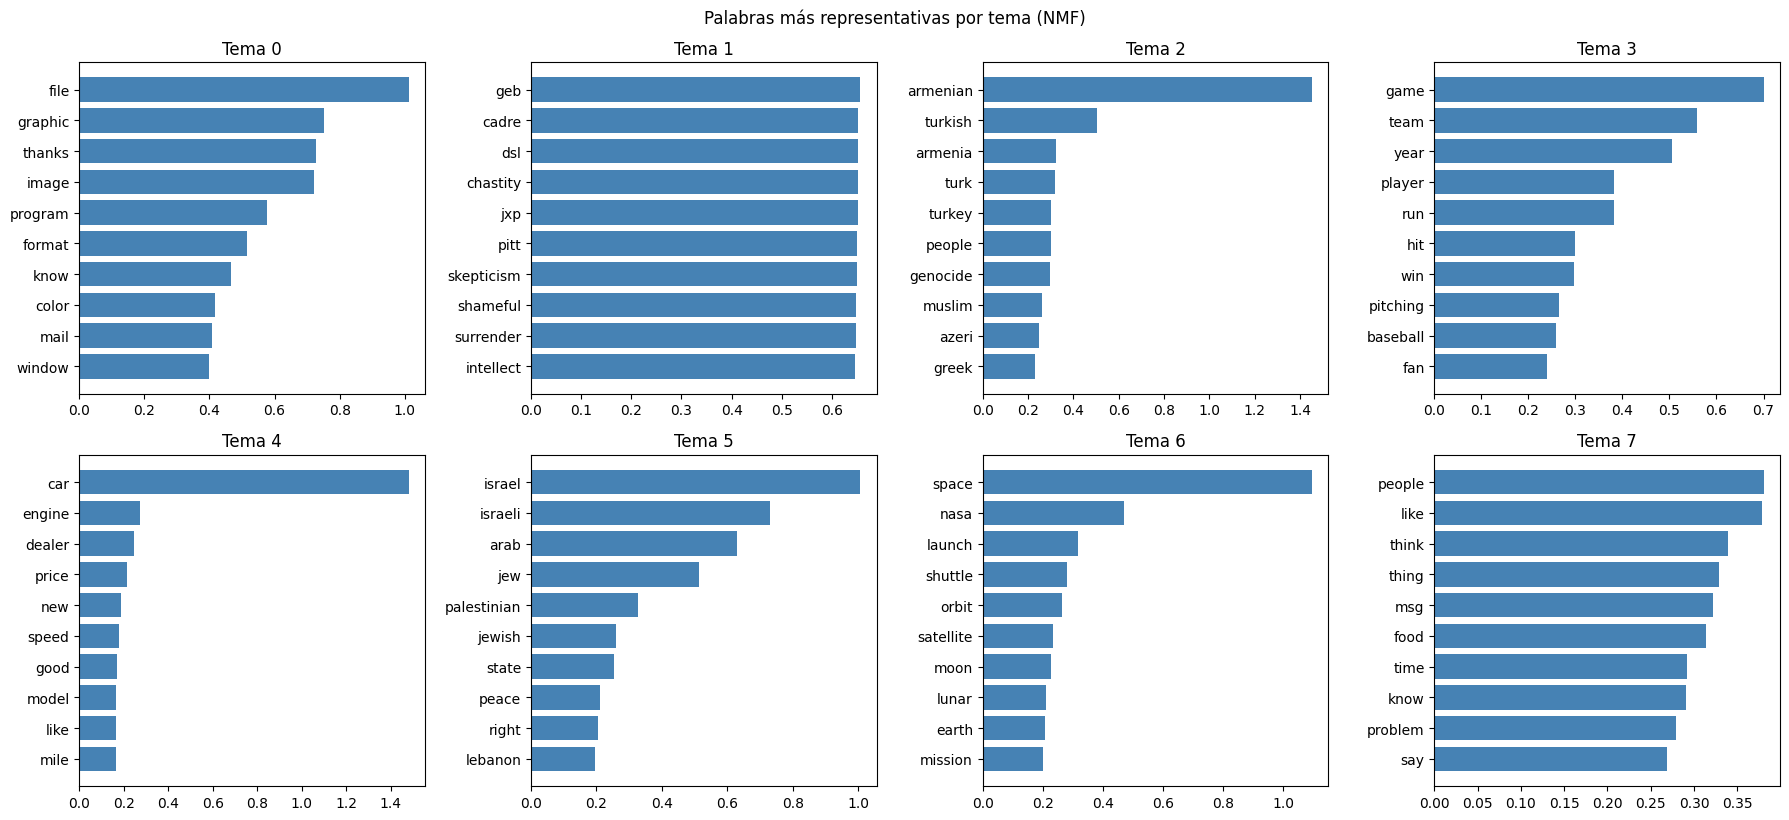

In [ ]:
# Visualización de las palabras más representativas de cada tema
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[::-1][:10]
    top_palabras = [feature_names[i] for i in top_indices]
    top_pesos = topic[top_indices]

    ax = axes[topic_idx]
    ax.barh(range(len(top_palabras)), top_pesos, color='steelblue')
    ax.set_yticks(range(len(top_palabras)))
    ax.set_yticklabels(top_palabras)
    ax.invert_yaxis()
    ax.set_title(f'Tema {topic_idx}')

plt.tight_layout()
plt.suptitle('Palabras más representativas por tema (NMF)', y=1.02)
plt.show()

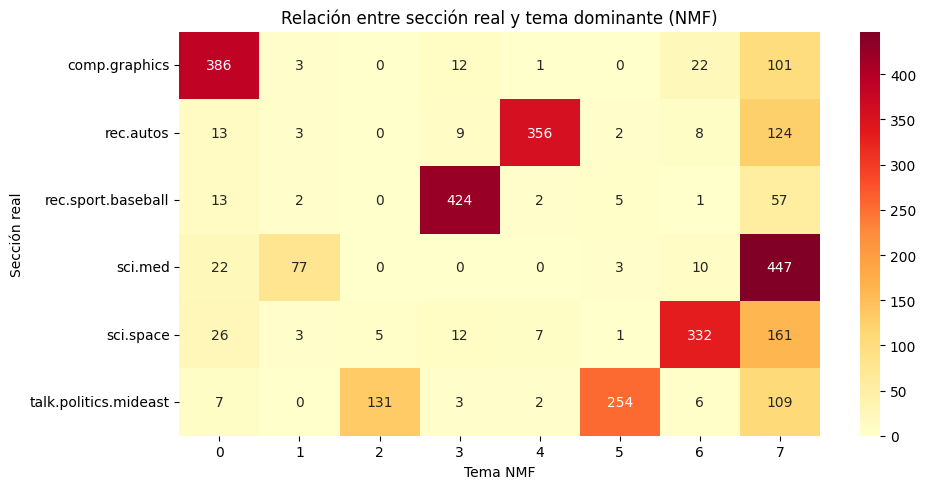

In [ ]:
# Relación entre los temas descubiertos por NMF y las secciones reales del periódico
df['tema_dominante'] = W.argmax(axis=1)

tabla_relacion = pd.crosstab(df['categoria'], df['tema_dominante'])
plt.figure(figsize=(10, 5))
sns.heatmap(tabla_relacion, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Relación entre sección real y tema dominante (NMF)')
plt.xlabel('Tema NMF')
plt.ylabel('Sección real')
plt.tight_layout()
plt.show()

## 6. Motor de recomendación

Cada artículo ya está representado como un vector de temas (fila de **W**). Para recomendar artículos similares al que el lector está viendo:

1. Tomamos el vector de temas del artículo actual.
2. Calculamos la **similitud de coseno** contra los vectores de temas de todos los demás artículos.
3. Devolvemos los N artículos con mayor similitud (excluyendo el propio artículo).

In [ ]:
# Matriz de similitud de coseno entre todos los artículos (en el espacio de temas NMF)
similitud_matrix = cosine_similarity(W)
print(f"Matriz de similitud: {similitud_matrix.shape}")

def recomendar_articulos(indice_articulo, n_recomendaciones=5):
    """Recomienda los artículos más similares a uno dado, usando similitud de coseno sobre el espacio de temas NMF"""
    similitudes = similitud_matrix[indice_articulo]

    # Ordenar por similitud descendente, excluyendo el propio artículo
    indices_similares = similitudes.argsort()[::-1]
    indices_similares = [i for i in indices_similares if i != indice_articulo][:n_recomendaciones]

    resultados = df.loc[indices_similares, ['categoria', 'texto']].copy()
    resultados['similitud'] = similitudes[indices_similares]
    resultados['extracto'] = resultados['texto'].str.slice(0, 150) + '...'

    return resultados[['categoria', 'similitud', 'extracto']]

Matriz de similitud: (3162, 3162)


In [ ]:
# Ejemplo: un lector está viendo el siguiente artículo
indice_ejemplo = 0

print("=== ARTÍCULO ACTUAL ===")
print(f"Sección: {df.loc[indice_ejemplo, 'categoria']}")
print(f"Texto: {df.loc[indice_ejemplo, 'texto'][:400]}...")

print("\n=== ARTÍCULOS RECOMENDADOS (más similares) ===")
recomendaciones = recomendar_articulos(indice_ejemplo, n_recomendaciones=5)
recomendaciones

=== ARTÍCULO ACTUAL ===
Sección: comp.graphics
Texto: I am currently looking for a 3D graphics library that runs on MS
Windows 3.1.  Are there any such libraries out there other than
Visuallib?  (It must run on VGA and should not require any other
add-on graphics cards).

For Visuallib, will it run with Metaware High C compiler v3.0?  Any
email contact for the author of Visuallib?

Any help would be much appreciated.  Thanks.

...

=== ARTÍCULOS RECOMENDADOS (más similares) ===


,categoria,similitud,extracto
1852,comp.graphics,0.997500,I am interested in a 2d/3d graphics library wh...
2545,rec.sport.baseball,0.996037,I have tickets for the TB Giants and I was won...
774,comp.graphics,0.995490,"\nGraeme> \tYes, that's known as ""Bresenhams R..."
2142,comp.graphics,0.991430,\nThere are 2 books published by M&T BOOKS tha...
1834,comp.graphics,0.991426,"Hi everybody,\n\nCan anyone name an anonymous ..."


In [ ]:
# Otro ejemplo, con un artículo de una sección distinta
indice_ejemplo_2 = df[df['categoria'] == 'sci.space'].index[0]

print("=== ARTÍCULO ACTUAL ===")
print(f"Sección: {df.loc[indice_ejemplo_2, 'categoria']}")
print(f"Texto: {df.loc[indice_ejemplo_2, 'texto'][:400]}...")

print("\n=== ARTÍCULOS RECOMENDADOS (más similares) ===")
recomendar_articulos(indice_ejemplo_2, n_recomendaciones=5)

=== ARTÍCULO ACTUAL ===
Sección: sci.space
Texto: Hi,
  
  I'm writing a science fiction script and I'm looking for some
answers to questions regarding the Moon and Earth. My starting point
is an impossible situation.  [I checked with a professor at berkeley
and his response was a VERY helpful "can't happen".] If you enjoy
playing with unusual ideas and are willing answer some questions
please contact me via e-mail (jennise@dgi.com).

  I get ext...

=== ARTÍCULOS RECOMENDADOS (más similares) ===


,categoria,similitud,extracto
1685,comp.graphics,0.984424,\n\nThe equation of the sphere through the 4 p...
1689,talk.politics.mideast,0.977669,\nIf you want info claiming that blacks were b...
2089,sci.space,0.976248,"If gamma ray bursters are extragalactic, would..."
3068,comp.graphics,0.974033,\n\n\nIt's not a bad question: I don't have an...
2883,sci.med,0.973943,I seem to recall that there was an article in ...


## 7. Evaluación del sistema de recomendación

Como tenemos la sección real de cada artículo (aunque el modelo no la usó para entrenar), podemos medir qué proporción de los artículos recomendados pertenece a la **misma sección** que el artículo consultado. Esto sirve como una validación indirecta de que el sistema recomienda contenido temáticamente similar.

In [ ]:
def evaluar_precision_seccion(n_recomendaciones=5, n_muestras=200):
    """Calcula qué porcentaje de las recomendaciones pertenecen a la misma sección que el artículo consultado"""
    indices_muestra = np.random.choice(len(df), size=min(n_muestras, len(df)), replace=False)

    aciertos = 0
    total = 0

    for idx in indices_muestra:
        categoria_real = df.loc[idx, 'categoria']
        recomendaciones = recomendar_articulos(idx, n_recomendaciones)

        aciertos += (recomendaciones['categoria'] == categoria_real).sum()
        total += n_recomendaciones

    return aciertos / total

precision = evaluar_precision_seccion(n_recomendaciones=5, n_muestras=200)
print(f"Precisión del sistema (recomendaciones de la misma sección): {precision*100:.2f}%")
print("\n(Un valor considerablemente mayor al que se obtendría al recomendar artículos al azar")
print(f" -que sería aproximadamente {100/df['categoria'].nunique():.2f}%- indica que el sistema")
print(" está capturando bien la similitud temática entre artículos.)")

Precisión del sistema (recomendaciones de la misma sección): 79.70%

(Un valor considerablemente mayor al que se obtendría al recomendar artículos al azar
 -que sería aproximadamente 16.67%- indica que el sistema
 está capturando bien la similitud temática entre artículos.)


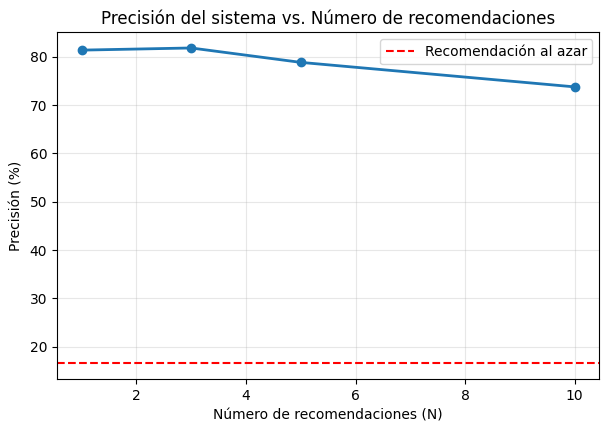

In [ ]:
# Precisión para distintos valores de N (número de recomendaciones)
valores_n = [1, 3, 5, 10]
precisiones_n = [evaluar_precision_seccion(n_recomendaciones=n, n_muestras=150) for n in valores_n]

plt.figure(figsize=(7, 4.5))
plt.plot(valores_n, [p*100 for p in precisiones_n], marker='o', linewidth=2)
plt.axhline(y=100/df['categoria'].nunique(), color='r', linestyle='--', label='Recomendación al azar')
plt.xlabel('Número de recomendaciones (N)')
plt.ylabel('Precisión (%)')
plt.title('Precisión del sistema vs. Número de recomendaciones')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Recomendación para un artículo nuevo (fuera del dataset)

En un escenario real, el "artículo actual" que el lector está viendo puede ser nuevo (no estar en el conjunto de entrenamiento). Para eso, transformamos el texto nuevo usando el mismo vectorizador TF-IDF y el mismo modelo NMF ya entrenados, y calculamos su similitud contra los artículos existentes.

In [ ]:
def recomendar_para_texto_nuevo(texto_nuevo, n_recomendaciones=5):
    """Recomienda artículos similares a un texto nuevo, no visto durante el entrenamiento"""
    texto_limpio = clean_text(texto_nuevo)

    vector_tfidf = tfidf_vectorizer.transform([texto_limpio])
    vector_tema = nmf_model.transform(vector_tfidf)  # proyección al espacio de temas aprendido

    similitudes = cosine_similarity(vector_tema, W).flatten()
    indices_similares = similitudes.argsort()[::-1][:n_recomendaciones]

    resultados = df.loc[indices_similares, ['categoria', 'texto']].copy()
    resultados['similitud'] = similitudes[indices_similares]
    resultados['extracto'] = resultados['texto'].str.slice(0, 150) + '...'

    return resultados[['categoria', 'similitud', 'extracto']]

# Ejemplo con un artículo nuevo sobre astronomía / exploración espacial
articulo_nuevo = """
NASA announced a new mission to study the surface of Mars using an advanced
rover equipped with spectrometers and cameras. The spacecraft will orbit
the planet before descending to collect soil samples and search for signs
of ancient microbial life. Scientists are excited about the potential
discoveries this mission could bring to our understanding of the solar system.
"""

print("=== ARTÍCULO NUEVO ===")
print(articulo_nuevo.strip())

print("\n=== ARTÍCULOS RECOMENDADOS ===")
recomendar_para_texto_nuevo(articulo_nuevo, n_recomendaciones=5)

=== ARTÍCULO NUEVO ===
NASA announced a new mission to study the surface of Mars using an advanced
rover equipped with spectrometers and cameras. The spacecraft will orbit
the planet before descending to collect soil samples and search for signs
of ancient microbial life. Scientists are excited about the potential
discoveries this mission could bring to our understanding of the solar system.

=== ARTÍCULOS RECOMENDADOS ===


,categoria,similitud,extracto
2154,sci.space,0.999976,Seems that the Mile-Long Billboard and any oth...
2968,sci.space,0.999966,"\nA practical suggestion, to be sure, but one ..."
1780,sci.space,0.999962,SSF is up for redesign again. Let's do it rig...
2515,sci.space,0.999949,\nPortuguese launch complex??? Gosh.... Polish...
1783,sci.space,0.999938,...\n\nFunny. A bit disturbing. Forging a po...


## 9. Conclusiones

- **NMF** permite descomponer la colección de artículos en un conjunto reducido de temas interpretables, cada uno definido por sus palabras clave más representativas (por ejemplo: espacio/astronomía, medicina, autos, deportes, gráficos por computadora, política internacional).
- Representar los artículos en el espacio de temas (en vez del espacio TF-IDF original, de miles de dimensiones) permite calcular **similitud de coseno** de forma eficiente y con mejores resultados, ya que se compara por "contenido temático" en lugar de coincidencia exacta de palabras.
- La evaluación mostró que la precisión de recomendar artículos de la misma sección real es significativamente mayor que una recomendación aleatoria, lo que valida que el sistema captura similitud temática genuina.
- El sistema generaliza a **artículos nuevos** (no vistos en el entrenamiento): basta con proyectarlos al espacio de temas ya aprendido con el vectorizador y el modelo NMF ya ajustados (`transform`, sin volver a entrenar).
- Este enfoque (TF-IDF + NMF + similitud de coseno) es una solución clásica, ligera y explicable para sistemas de recomendación de contenido basados en similitud temática, sin necesidad de redes neuronales ni grandes volúmenes de datos de interacción de usuarios (a diferencia del filtrado colaborativo).